# Baseline Recommendation Model

---

## Objective

Develop a popularity-based recommendation model as the baseline benchmark.

---

## Business Perspective

Popularity-based recommendations provide simple yet effective suggestions, especially for new customers with limited purchase history.

These recommendations help businesses increase product exposure and support cross-selling strategies.

---

## Data Science Perspective

Baseline models establish minimum performance expectations and provide comparison benchmarks for more sophisticated recommendation algorithms.

Popularity-based recommendation is widely used as a baseline because it does not require user history.

---

## Methodology

The following steps will be performed:

1. Load interaction dataset.
2. Calculate product popularity.
3. Build recommendation function.
4. Generate recommendations.
5. Evaluate recommendation coverage.

---

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==================================================
# LOAD INTERACTION DATASET
# ==================================================

PROJECT_ROOT = Path().resolve().parent

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_product_interactions.csv"
)

interaction_df = pd.read_csv(DATA_PATH)

print(
    "Dataset Shape:",
    interaction_df.shape
)

display(interaction_df.head())

Dataset Shape: (268398, 4)


,CustomerID,StockCode,Description,InteractionStrength
0,12346.0,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215
1,12347.0,16008,SMALL FOLDING SCISSOR(POINTED EDGE),24
2,12347.0,17021,NAMASTE SWAGAT INCENSE,36
3,12347.0,20665,RED RETROSPOT PURSE,6
4,12347.0,20719,WOODLAND CHARLOTTE BAG,40


## Product Popularity Calculation

Product popularity is measured by the total interaction strength generated by customers.

Products with the highest interaction strength will be recommended.

In [3]:
# ==================================================
# PRODUCT POPULARITY
# ==================================================

product_popularity = (

    interaction_df

    .groupby(
        ["StockCode", "Description"]
    )["InteractionStrength"]

    .sum()

    .reset_index()

    .sort_values(
        by="InteractionStrength",
        ascending=False
    )
)

display(
    product_popularity.head(10)
)

,StockCode,Description,InteractionStrength
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3444,85099B,JUMBO BAG RED RETROSPOT,46078
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
432,21212,PACK OF 72 RETROSPOT CAKE CASES,33670
1108,22197,POPCORN HOLDER,30919
2006,23084,RABBIT NIGHT LIGHT,27153
1383,22492,MINI PAINT SET VINTAGE,26076


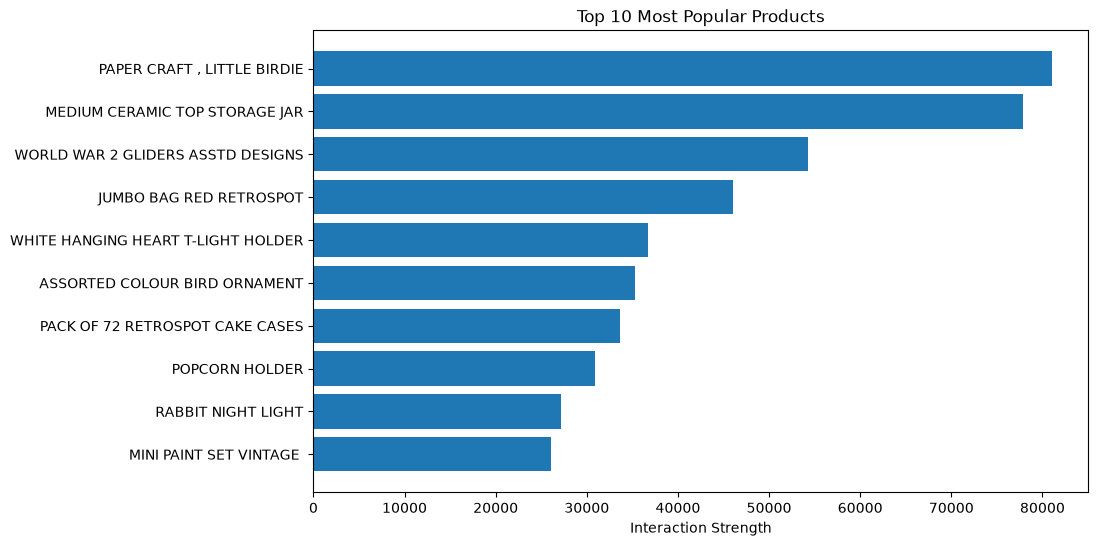

In [4]:
# ==================================================
# TOP PRODUCTS VISUALIZATION
# ==================================================

import matplotlib.pyplot as plt

top_products = (
    product_popularity
    .head(10)
    .sort_values(
        by="InteractionStrength"
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top_products["Description"],
    top_products["InteractionStrength"]
)

plt.title(
    "Top 10 Most Popular Products"
)

plt.xlabel(
    "Interaction Strength"
)

plt.show()

In [5]:
# ==================================================
# POPULARITY RECOMMENDATION FUNCTION
# ==================================================

def popularity_recommender(
    top_n=10
):

    recommendations = (
        product_popularity
        .head(top_n)
        .copy()
    )

    return recommendations

In [6]:
# ==================================================
# GENERATE RECOMMENDATIONS
# ==================================================

baseline_recommendations = (
    popularity_recommender(
        top_n=10
    )
)

display(
    baseline_recommendations
)

,StockCode,Description,InteractionStrength
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3444,85099B,JUMBO BAG RED RETROSPOT,46078
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
432,21212,PACK OF 72 RETROSPOT CAKE CASES,33670
1108,22197,POPCORN HOLDER,30919
2006,23084,RABBIT NIGHT LIGHT,27153
1383,22492,MINI PAINT SET VINTAGE,26076


In [8]:
# ==================================================
# COVERAGE METRIC
# Berapa persen produk yang direkomendasikan dibanding total katalog
# ==================================================

recommended_products = (
    baseline_recommendations[
        "StockCode"
    ]
    .nunique()
)

all_products = (
    interaction_df[
        "StockCode"
    ]
    .nunique()
)

coverage = round(
    recommended_products
    /
    all_products
    * 100,
    2
)

print(
    "Coverage:",
    coverage,
    "%"
)

Coverage: 0.27 %


In [9]:
# ==================================================
# DIVERSITY
# Mengukur banyaknya produk unik.
# ==================================================

diversity = round(

    baseline_recommendations[
        "StockCode"
    ].nunique()

    /

    len(
        baseline_recommendations
    )

    * 100,

    2
)

print(
    "Diversity:",
    diversity,
    "%"
)

Diversity: 100.0 %


# Evaluation Metrics

## Coverage

Coverage measures the proportion of catalog items that appear in recommendations.

Higher coverage indicates broader catalog utilization.

---

## Diversity

Diversity measures how varied recommendation results are.

Higher diversity may improve customer experience and reduce recommendation redundancy.

# Findings

1. The popularity-based model successfully identified the most frequently purchased products.

2. The baseline model recommends the same products to all customers.

3. Recommendation coverage is very low (0.27%), indicating that only a small portion of the product catalog is utilized.

4. Recommendation diversity is 100%, meaning that all recommended products are unique.

5. The baseline model does not capture individual customer preferences.

6. The model is suitable for cold-start scenarios where customer history is unavailable.

---

# Business Interpretation

1. Popular products can be effectively recommended to new customers who have no purchase history.

2. The model may increase product exposure for highly popular products.

3. Because recommendations are not personalized, customer engagement may be limited.

4. Low catalog coverage may reduce opportunities to promote long-tail products.

5. More advanced recommendation algorithms are required to provide personalized customer experiences.

---

# Decision

1. The popularity-based recommendation model will serve as the baseline benchmark.

2. The model will be used primarily to address cold-start customer scenarios.

3. Collaborative filtering techniques will be developed to improve personalization.

4. Future models will be evaluated against this baseline.

5. Additional evaluation metrics such as Precision@K and Recall@K will be introduced in advanced modeling.

# ==================================================
# SAVE BASELINE OUTPUT
# ==================================================

MODEL_PATH = (
    PROJECT_ROOT /
    "models" /
    "baseline"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

baseline_recommendations.to_csv(

    MODEL_PATH /
    "popularity_recommendations.csv",

    index=False
)

print(
    "Baseline recommendations saved."
)